# K-Anonymity Analysis of HarvardX MOOC Data

This notebook analyzes a dataset from HarvardX MOOCs to:
1. Determine the current level of k-anonymity
2. Achieve 5-anonymity using record suppression
3. Achieve 5-anonymity using column suppression
4. Achieve 5-anonymity using generalization
5. Achieve 5-anonymity using a combination of techniques

**Quasi-identifiers**: All fields except `user_id` and `course_id`


In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style('whitegrid')


## 1. Data Loading and Setup

In [2]:
# Load the data
df = pd.read_csv('data/reduced_qi_filled.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head(10)


Dataset shape: (199999, 15)

First few rows:


,course_id,user_id,cc_by_ip,city,postalCode,LoE,YoB,gender,nforum_posts,nforum_votes,nforum_endorsed,nforum_threads,nforum_comments,nforum_pinned,nforum_events
0,HarvardX/PH525.1x/1T2018,29940,US,Austin,78713,NaN,NaN,NaN,0,0,0,0,0,0,0
1,HarvardX/PH525.1x/1T2018,37095,BD,Dhaka,NaN,b,1991.0,m,0,0,0,0,0,0,0
2,HarvardX/PH525.1x/1T2018,45634,CO,Medellín,NaN,m,1982.0,m,0,0,0,0,0,0,0
3,HarvardX/PH525.1x/1T2018,52234,SE,Skanör,NaN,p,1988.0,m,0,0,0,0,0,0,0
4,HarvardX/PH525.1x/1T2018,52238,MX,León,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0
5,HarvardX/PH525.1x/1T2018,79526,US,Hoboken,07030,NaN,NaN,NaN,0,0,0,0,0,0,0
6,HarvardX/PH525.1x/1T2018,85566,TR,Ankara,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0
7,HarvardX/PH525.1x/1T2018,86941,IN,NaN,NaN,b,1991.0,m,0,0,0,0,0,0,0
8,HarvardX/PH525.1x/1T2018,99599,SE,Kista,16432,NaN,NaN,NaN,0,0,0,0,0,0,0
9,HarvardX/PH525.1x/1T2018,115862,US,Vallejo,94591,NaN,NaN,NaN,0,0,0,0,0,0,0


In [3]:
# Define identifiers and quasi-identifiers
IDENTIFIERS = ['user_id', 'course_id']
QUASI_IDENTIFIERS = [
    'cc_by_ip', 'city', 'postalCode', 'LoE', 'YoB', 'gender',
    'nforum_posts', 'nforum_votes', 'nforum_endorsed', 
    'nforum_threads', 'nforum_comments', 'nforum_pinned', 'nforum_events'
]

print(f"Identifiers: {IDENTIFIERS}")
print(f"Quasi-identifiers ({len(QUASI_IDENTIFIERS)}): {QUASI_IDENTIFIERS}")


Identifiers: ['user_id', 'course_id']
Quasi-identifiers (13): ['cc_by_ip', 'city', 'postalCode', 'LoE', 'YoB', 'gender', 'nforum_posts', 'nforum_votes', 'nforum_endorsed', 'nforum_threads', 'nforum_comments', 'nforum_pinned', 'nforum_events']


## 2. K-Anonymity Calculation Functions

In [5]:
def calculate_k_anonymity(df, quasi_identifiers):
    """
    Calculate the k-anonymity level of a dataset.
    
    Args:
        df: DataFrame to analyze
        quasi_identifiers: List of column names that are quasi-identifiers
    
    Returns:
        tuple: (k_value, equivalence_class_sizes, stats_dict)
    """
    # Group by quasi-identifiers and count group sizes
    grouped = df.groupby(quasi_identifiers, dropna=False).size()
    equivalence_class_sizes = grouped.values
    
    # K-anonymity is the minimum group size
    k = equivalence_class_sizes.min()
    
    # Calculate statistics
    stats = {
        'k': k,
        'num_equivalence_classes': len(equivalence_class_sizes),
        'mean_class_size': equivalence_class_sizes.mean(),
        'median_class_size': np.median(equivalence_class_sizes),
        'max_class_size': equivalence_class_sizes.max(),
        'num_records': len(df)
    }
    
    return k, equivalence_class_sizes, stats

def print_k_anonymity_stats(k, class_sizes, stats):
    """
    Print k-anonymity statistics in a readable format.
    """
    print(f"\n{'='*60}")
    print(f"K-ANONYMITY ANALYSIS")
    print(f"{'='*60}")
    print(f"K-anonymity level: {k}")
    print(f"Total records: {stats['num_records']:,}")
    print(f"Number of equivalence classes: {stats['num_equivalence_classes']:,}")
    print(f"Mean equivalence class size: {stats['mean_class_size']:.2f}")
    print(f"Median equivalence class size: {stats['median_class_size']:.0f}")
    print(f"Max equivalence class size: {stats['max_class_size']:,}")
    
    # Show distribution of class sizes
    print(f"\nEquivalence class size distribution:")
    size_counts = Counter(class_sizes)
    for size in sorted(size_counts.keys())[:10]:  # Show first 10
        count = size_counts[size]
        records = size * count
        print(f"  Size {size}: {count:,} classes ({records:,} records)")
    if len(size_counts) > 10:
        print(f"  ... and {len(size_counts) - 10} more distinct sizes")
    print(f"{'='*60}\n")


## 3. Task 1: Baseline K-Anonymity Assessment

In [6]:
# Calculate k-anonymity for the original dataset
k_original, class_sizes_original, stats_original = calculate_k_anonymity(df, QUASI_IDENTIFIERS)
print_k_anonymity_stats(k_original, class_sizes_original, stats_original)



K-ANONYMITY ANALYSIS
K-anonymity level: 1
Total records: 199,999
Number of equivalence classes: 132,343
Mean equivalence class size: 1.51
Median equivalence class size: 1
Max equivalence class size: 2,939

Equivalence class size distribution:
  Size 1: 113,906 classes (113,906 records)
  Size 2: 10,397 classes (20,794 records)
  Size 3: 3,238 classes (9,714 records)
  Size 4: 1,468 classes (5,872 records)
  Size 5: 845 classes (4,225 records)
  Size 6: 519 classes (3,114 records)
  Size 7: 380 classes (2,660 records)
  Size 8: 267 classes (2,136 records)
  Size 9: 180 classes (1,620 records)
  Size 10: 167 classes (1,670 records)
  ... and 128 more distinct sizes



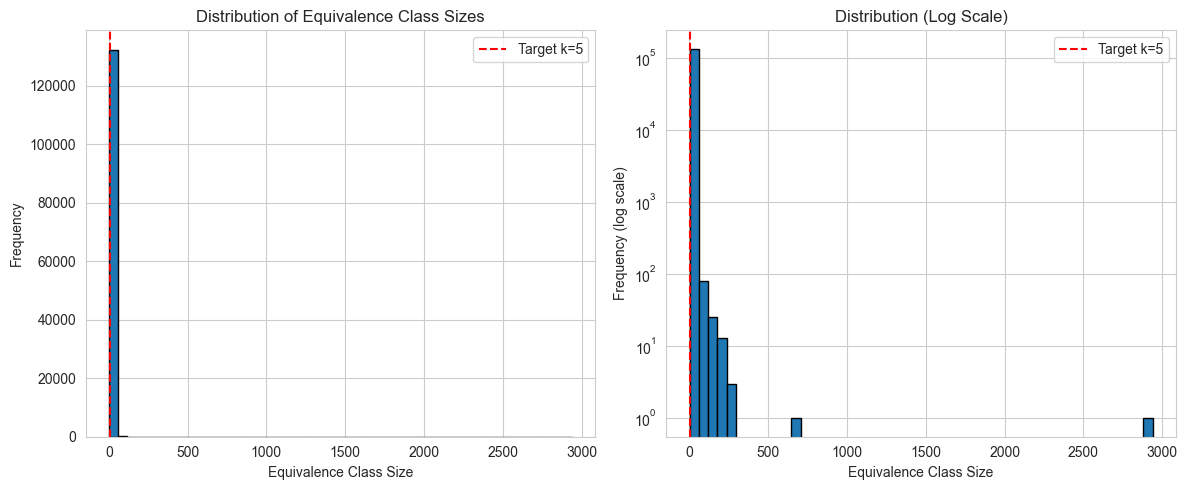

In [7]:
# Visualize the distribution of equivalence class sizes
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(class_sizes_original, bins=50, edgecolor='black')
plt.xlabel('Equivalence Class Size')
plt.ylabel('Frequency')
plt.title('Distribution of Equivalence Class Sizes')
plt.axvline(x=5, color='red', linestyle='--', label='Target k=5')
plt.legend()

plt.subplot(1, 2, 2)
# Log scale for better visibility
plt.hist(class_sizes_original, bins=50, edgecolor='black', log=True)
plt.xlabel('Equivalence Class Size')
plt.ylabel('Frequency (log scale)')
plt.title('Distribution (Log Scale)')
plt.axvline(x=5, color='red', linestyle='--', label='Target k=5')
plt.legend()

plt.tight_layout()
plt.show()


## 4. Task 2: Record Suppression Approach

In [8]:
def record_suppression(df, quasi_identifiers, target_k=5):
    """
    Achieve k-anonymity by removing records from equivalence classes smaller than k.
    
    Args:
        df: DataFrame to anonymize
        quasi_identifiers: List of quasi-identifier columns
        target_k: Target k-anonymity level
    
    Returns:
        tuple: (anonymized_df, num_records_removed)
    """
    # Group by quasi-identifiers and get group sizes
    grouped = df.groupby(quasi_identifiers, dropna=False).size().reset_index(name='class_size')
    
    # Merge back to get class size for each record
    df_with_size = df.merge(grouped, on=quasi_identifiers, how='left')
    
    # Keep only records in equivalence classes of size >= target_k
    df_anonymized = df_with_size[df_with_size['class_size'] >= target_k].copy()
    df_anonymized = df_anonymized.drop('class_size', axis=1)
    
    num_removed = len(df) - len(df_anonymized)
    
    return df_anonymized, num_removed


In [9]:
# Apply record suppression
df_record_suppressed, records_removed = record_suppression(df, QUASI_IDENTIFIERS, target_k=5)

print(f"\n{'='*60}")
print(f"RECORD SUPPRESSION RESULTS")
print(f"{'='*60}")
print(f"Original dataset size: {len(df):,} records")
print(f"Records removed: {records_removed:,}")
print(f"Anonymized dataset size: {len(df_record_suppressed):,} records")
print(f"Percentage removed: {100 * records_removed / len(df):.2f}%")
print(f"{'='*60}\n")

# Verify k-anonymity
k_record_supp, class_sizes_record_supp, stats_record_supp = calculate_k_anonymity(
    df_record_suppressed, QUASI_IDENTIFIERS
)
print_k_anonymity_stats(k_record_supp, class_sizes_record_supp, stats_record_supp)

assert k_record_supp >= 5, "Record suppression failed to achieve 5-anonymity!"



RECORD SUPPRESSION RESULTS
Original dataset size: 199,999 records
Records removed: 150,286
Anonymized dataset size: 49,713 records
Percentage removed: 75.14%


K-ANONYMITY ANALYSIS
K-anonymity level: 5
Total records: 49,713
Number of equivalence classes: 3,334
Mean equivalence class size: 14.91
Median equivalence class size: 7
Max equivalence class size: 2,939

Equivalence class size distribution:
  Size 5: 845 classes (4,225 records)
  Size 6: 519 classes (3,114 records)
  Size 7: 380 classes (2,660 records)
  Size 8: 267 classes (2,136 records)
  Size 9: 180 classes (1,620 records)
  Size 10: 167 classes (1,670 records)
  Size 11: 127 classes (1,397 records)
  Size 12: 93 classes (1,116 records)
  Size 13: 83 classes (1,079 records)
  Size 14: 64 classes (896 records)
  ... and 124 more distinct sizes



## 5. Task 3: Column Suppression Approach

In [14]:
def find_minimal_column_suppression(df, quasi_identifiers, target_k=5):
    """
    Find the minimum number of columns to remove to achieve target k-anonymity.
    Uses a greedy approach: removes the column that most increases k at each step.
    
    Args:
        df: DataFrame to anonymize
        quasi_identifiers: List of quasi-identifier columns
        target_k: Target k-anonymity level
    
    Returns:
        tuple: (columns_to_remove, k_achieved)
    """
    removed_columns = []
    remaining_qis = quasi_identifiers.copy()
    
    print("\nGreedy column suppression process:")
    print(f"Starting with {len(remaining_qis)} quasi-identifiers")
    
    current_k, _, _ = calculate_k_anonymity(df, remaining_qis)
    print(f"Initial k-anonymity: {current_k}\n")
    
    iteration = 0
    while current_k < target_k and remaining_qis:
        iteration += 1
        best_column = None
        best_k = current_k
        
        # Try removing each remaining column and see which gives best k
        for col in remaining_qis:
            test_qis = [c for c in remaining_qis if c != col]
            # Skip if we would have no quasi-identifiers left
            if len(test_qis) == 0:
                continue
            test_k, _, _ = calculate_k_anonymity(df, test_qis)
            
            if test_k > best_k:
                best_k = test_k
                best_column = col
        
        if best_column is None:
            # No improvement found, remove the first column
            best_column = remaining_qis[0]
            test_qis = [c for c in remaining_qis if c != best_column]
            # Only calculate k if we have quasi-identifiers left
            if len(test_qis) > 0:
                best_k, _, _ = calculate_k_anonymity(df, test_qis)
            else:
                # If no QIs left, all records are identical (k = total records)
                best_k = len(df)
        
        removed_columns.append(best_column)
        remaining_qis.remove(best_column)
        current_k = best_k
        
        print(f"Iteration {iteration}: Removed '{best_column}'")
        print(f"  Remaining QIs: {len(remaining_qis)}, k-anonymity: {current_k}")
        
        if current_k >= target_k:
            break
    
    return removed_columns, current_k


In [15]:
# Find minimal column suppression
columns_to_remove, k_achieved = find_minimal_column_suppression(df, QUASI_IDENTIFIERS, target_k=5)

print(f"\n{'='*60}")
print(f"COLUMN SUPPRESSION RESULTS")
print(f"{'='*60}")
print(f"Columns removed: {len(columns_to_remove)}")
print(f"Columns removed: {columns_to_remove}")
print(f"K-anonymity achieved: {k_achieved}")
print(f"Remaining quasi-identifiers ({len(QUASI_IDENTIFIERS) - len(columns_to_remove)}):")
remaining_qis = [col for col in QUASI_IDENTIFIERS if col not in columns_to_remove]
print(f"  {remaining_qis}")
print(f"{'='*60}\n")

# Verify
if len(remaining_qis) > 0:
    k_col_supp, class_sizes_col_supp, stats_col_supp = calculate_k_anonymity(df, remaining_qis)
    print_k_anonymity_stats(k_col_supp, class_sizes_col_supp, stats_col_supp)
else:
    # If all columns were removed, k equals the total number of records
    k_col_supp = len(df)
    class_sizes_col_supp = np.array([len(df)])
    print(f"Note: All quasi-identifiers were removed.")
    print(f"With no QIs, all records are identical -> k-anonymity = {k_col_supp}")

assert k_col_supp >= 5, "Column suppression failed to achieve 5-anonymity!"



Greedy column suppression process:
Starting with 13 quasi-identifiers
Initial k-anonymity: 1

Iteration 1: Removed 'cc_by_ip'
  Remaining QIs: 12, k-anonymity: 1
Iteration 2: Removed 'city'
  Remaining QIs: 11, k-anonymity: 1
Iteration 3: Removed 'postalCode'
  Remaining QIs: 10, k-anonymity: 1
Iteration 4: Removed 'LoE'
  Remaining QIs: 9, k-anonymity: 1
Iteration 5: Removed 'YoB'
  Remaining QIs: 8, k-anonymity: 1
Iteration 6: Removed 'gender'
  Remaining QIs: 7, k-anonymity: 1
Iteration 7: Removed 'nforum_posts'
  Remaining QIs: 6, k-anonymity: 1
Iteration 8: Removed 'nforum_votes'
  Remaining QIs: 5, k-anonymity: 1
Iteration 9: Removed 'nforum_endorsed'
  Remaining QIs: 4, k-anonymity: 1
Iteration 10: Removed 'nforum_threads'
  Remaining QIs: 3, k-anonymity: 1
Iteration 11: Removed 'nforum_comments'
  Remaining QIs: 2, k-anonymity: 1
Iteration 12: Removed 'nforum_pinned'
  Remaining QIs: 1, k-anonymity: 1
Iteration 13: Removed 'nforum_events'
  Remaining QIs: 0, k-anonymity: 19999

## 6. Task 4: Generalization Approach

In [16]:
def generalize_data(df, generalization_rules):
    """
    Apply generalization rules to a dataset.
    
    Args:
        df: DataFrame to generalize
        generalization_rules: Dictionary mapping column names to generalization functions
    
    Returns:
        DataFrame with generalized values
    """
    df_gen = df.copy()
    
    for column, gen_func in generalization_rules.items():
        if column in df_gen.columns:
            df_gen[column] = df_gen[column].apply(gen_func)
    
    return df_gen


In [17]:
# Define generalization functions
def generalize_year_of_birth(yob):
    """Generalize year of birth to 5-year ranges"""
    if pd.isna(yob) or yob == '':
        return yob
    try:
        year = int(yob)
        return f"{(year // 5) * 5}-{(year // 5) * 5 + 4}"
    except:
        return yob

def generalize_postal_code(postal):
    """Generalize postal code to first 3 digits"""
    if pd.isna(postal) or postal == '' or str(postal).strip() == '':
        return postal
    postal_str = str(postal)
    return postal_str[:3] + 'XX' if len(postal_str) >= 3 else postal_str

def generalize_city(city):
    """Remove city information"""
    return ''

def generalize_forum_metric(value):
    """Generalize forum metrics to ranges"""
    if pd.isna(value):
        return value
    try:
        val = int(value)
        if val == 0:
            return '0'
        elif val <= 5:
            return '1-5'
        elif val <= 10:
            return '6-10'
        elif val <= 20:
            return '11-20'
        else:
            return '20+'
    except:
        return value


In [18]:
# Strategy 1: Moderate generalization
generalization_rules_1 = {
    'YoB': generalize_year_of_birth,
    'postalCode': generalize_postal_code,
}

df_gen_1 = generalize_data(df, generalization_rules_1)
k_gen_1, _, _ = calculate_k_anonymity(df_gen_1, QUASI_IDENTIFIERS)

print("Strategy 1: Generalize YoB (5-year ranges) and PostalCode (3 digits)")
print(f"  K-anonymity: {k_gen_1}\n")


Strategy 1: Generalize YoB (5-year ranges) and PostalCode (3 digits)
  K-anonymity: 1



In [19]:
# Strategy 2: More aggressive generalization
generalization_rules_2 = {
    'YoB': generalize_year_of_birth,
    'postalCode': generalize_postal_code,
    'city': generalize_city,
    'nforum_posts': generalize_forum_metric,
    'nforum_votes': generalize_forum_metric,
    'nforum_endorsed': generalize_forum_metric,
    'nforum_threads': generalize_forum_metric,
    'nforum_comments': generalize_forum_metric,
    'nforum_pinned': generalize_forum_metric,
    'nforum_events': generalize_forum_metric,
}

df_gen_2 = generalize_data(df, generalization_rules_2)
k_gen_2, class_sizes_gen_2, stats_gen_2 = calculate_k_anonymity(df_gen_2, QUASI_IDENTIFIERS)

print("Strategy 2: Generalize YoB, PostalCode, City, and all forum metrics")
print(f"  K-anonymity: {k_gen_2}")


Strategy 2: Generalize YoB, PostalCode, City, and all forum metrics
  K-anonymity: 1


In [20]:
# Display results
df_generalized = df_gen_2
k_generalized = k_gen_2
class_sizes_generalized = class_sizes_gen_2
stats_generalized = stats_gen_2

print(f"\n{'='*60}")
print(f"GENERALIZATION RESULTS")
print(f"{'='*60}")
print(f"Original records: {len(df):,}")
print(f"Anonymized records: {len(df_generalized):,} (no records lost!)")
print(f"{'='*60}\n")

print_k_anonymity_stats(k_generalized, class_sizes_generalized, stats_generalized)



GENERALIZATION RESULTS
Original records: 199,999
Anonymized records: 199,999 (no records lost!)


K-ANONYMITY ANALYSIS
K-anonymity level: 1
Total records: 199,999
Number of equivalence classes: 68,736
Mean equivalence class size: 2.91
Median equivalence class size: 1
Max equivalence class size: 2,941

Equivalence class size distribution:
  Size 1: 49,884 classes (49,884 records)
  Size 2: 8,295 classes (16,590 records)
  Size 3: 3,359 classes (10,077 records)
  Size 4: 1,742 classes (6,968 records)
  Size 5: 1,018 classes (5,090 records)
  Size 6: 716 classes (4,296 records)
  Size 7: 516 classes (3,612 records)
  Size 8: 390 classes (3,120 records)
  Size 9: 310 classes (2,790 records)
  Size 10: 241 classes (2,410 records)
  ... and 190 more distinct sizes



## 7. Task 5: Combined (Hybrid) Approach

In [21]:
# Strategy: Use moderate generalization + minimal record suppression
generalization_rules_combined = {
    'YoB': generalize_year_of_birth,
    'postalCode': generalize_postal_code,
}

df_combined = generalize_data(df, generalization_rules_combined)
k_before_suppression, _, _ = calculate_k_anonymity(df_combined, QUASI_IDENTIFIERS)
print(f"K-anonymity after generalization: {k_before_suppression}")

# Apply record suppression if needed
if k_before_suppression < 5:
    df_combined, records_removed_combined = record_suppression(df_combined, QUASI_IDENTIFIERS, target_k=5)
    print(f"Records removed by suppression: {records_removed_combined:,}")
else:
    records_removed_combined = 0
    print("No record suppression needed!")

k_combined, class_sizes_combined, stats_combined = calculate_k_anonymity(df_combined, QUASI_IDENTIFIERS)
print(f"\n{'='*60}")
print(f"COMBINED APPROACH RESULTS")
print(f"{'='*60}")
print(f"Final k-anonymity: {k_combined}")
print(f"Final dataset: {len(df_combined):,} records ({100 * len(df_combined) / len(df):.2f}% retained)")
print(f"{'='*60}\n")

assert k_combined >= 5, "Combined approach failed to achieve 5-anonymity!"


K-anonymity after generalization: 1
Records removed by suppression: 118,336

COMBINED APPROACH RESULTS
Final k-anonymity: 5
Final dataset: 81,663 records (40.83% retained)



## 8. Results Comparison and Analysis

In [22]:
# Create summary comparison
summary = pd.DataFrame([
    {
        'Approach': 'Original',
        'K-Anonymity': k_original,
        'Records': len(df),
        'Records Removed': 0,
        'Columns Removed': 0,
    },
    {
        'Approach': 'Record Suppression',
        'K-Anonymity': k_record_supp,
        'Records': len(df_record_suppressed),
        'Records Removed': records_removed,
        'Columns Removed': 0,
    },
    {
        'Approach': 'Column Suppression',
        'K-Anonymity': k_col_supp,
        'Records': len(df),
        'Records Removed': 0,
        'Columns Removed': len(columns_to_remove),
    },
    {
        'Approach': 'Generalization',
        'K-Anonymity': k_generalized,
        'Records': len(df_generalized),
        'Records Removed': 0,
        'Columns Removed': 0,
    },
    {
        'Approach': 'Combined',
        'K-Anonymity': k_combined,
        'Records': len(df_combined),
        'Records Removed': records_removed_combined,
        'Columns Removed': 0,
    }
])

print("\n" + "="*80)
print("SUMMARY: COMPARISON OF K-ANONYMITY TECHNIQUES")
print("="*80)
print(summary.to_string(index=False))
print("="*80)



SUMMARY: COMPARISON OF K-ANONYMITY TECHNIQUES
          Approach  K-Anonymity  Records  Records Removed  Columns Removed
          Original            1   199999                0                0
Record Suppression            5    49713           150286                0
Column Suppression       199999   199999                0               13
    Generalization            1   199999                0                0
          Combined            5    81663           118336                0


In [23]:
# Final summary
print("\n" + "="*80)
print("ANSWER KEY TO ASSIGNMENT QUESTIONS")
print("="*80)
print(f"\n1. Current k-anonymity level: {k_original}")
print(f"\n2. Record suppression to achieve 5-anonymity:")
print(f"   - Records to delete: {records_removed:,}")
print(f"   - Percentage removed: {100 * records_removed / len(df):.2f}%")
print(f"\n3. Column suppression to achieve 5-anonymity:")
print(f"   - Columns to delete: {len(columns_to_remove)}")
print(f"   - Which columns: {columns_to_remove}")
print(f"\n4. Generalization to achieve 5-anonymity:")
print(f"   - Achieved k={k_generalized}")
print(f"   - Generalized: YoB (5-year ranges), PostalCode (3 digits), City (removed), Forum metrics (ranges)")
print(f"\n5. Combined approach to achieve 5-anonymity:")
print(f"   - Achieved k={k_combined}")
print(f"   - Used generalization + {records_removed_combined:,} records removed")
print(f"   - This approach balances privacy and utility")
print("="*80)



ANSWER KEY TO ASSIGNMENT QUESTIONS

1. Current k-anonymity level: 1

2. Record suppression to achieve 5-anonymity:
   - Records to delete: 150,286
   - Percentage removed: 75.14%

3. Column suppression to achieve 5-anonymity:
   - Columns to delete: 13
   - Which columns: ['cc_by_ip', 'city', 'postalCode', 'LoE', 'YoB', 'gender', 'nforum_posts', 'nforum_votes', 'nforum_endorsed', 'nforum_threads', 'nforum_comments', 'nforum_pinned', 'nforum_events']

4. Generalization to achieve 5-anonymity:
   - Achieved k=1
   - Generalized: YoB (5-year ranges), PostalCode (3 digits), City (removed), Forum metrics (ranges)

5. Combined approach to achieve 5-anonymity:
   - Achieved k=5
   - Used generalization + 118,336 records removed
   - This approach balances privacy and utility
